In [49]:
# Imports 
import os
import math
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.transform import resize

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


#### Settings

In [50]:
# ============================================================
# SETTINGS
# ============================================================
dataset = 1   # 1..6

# Dataset convention:
#   1 -> YANIK
#   2 -> 3DRIED case 1
#   3 -> 3DRIED case 2
#   4 -> OURS case 1
#   5 -> OURS case 2
#   6 -> OURS screw_driver

raw_dataDir     = os.path.join(os.getcwd(), "sar_raw_data")
optical_ref_dir = os.path.join(os.getcwd(), "optical_refs")

# ------------------------------------------------------------
# RMIST SUPPORT FILES
# Replace these later with your actual files
# ------------------------------------------------------------
rmist_assets_dir = os.path.join(os.getcwd(), "rmist_assets")

phi_r_dag_mat_path = os.path.join(rmist_assets_dir, "Phi_r_dag_gun.mat")
phi_r_dag_varname  = "Phi_r_dag"

weights_path = os.path.join(rmist_assets_dir, "RMISTNet_weights.pth")

# Optional knobs
T_phases = 9
R_default_m = 0.185  # used only if you want a fixed R for kernel generation
EPS = 1e-12

#### Helper functions 

In [ ]:
# ============================================================
# HELPERS
# ============================================================

def load_first_field(mat_path):
    data = loadmat(mat_path)
    valid_keys = [k for k in data.keys() if not k.startswith("__")]
    if len(valid_keys) == 0:
        raise ValueError(f"No valid variables found in {mat_path}")
    return data[valid_keys[0]]

def image_quality_metrics(img):
    A = np.abs(img).astype(np.float64)
    A2 = A ** 2

    peak = np.max(A)
    denom2 = np.sum(A2) ** 2 + EPS
    contrast = np.sqrt(max(A.size * np.sum(A ** 4) / denom2 - 1, 0.0))

    p = A2 / (np.sum(A2) + EPS)
    entropy = -np.sum(p * np.log(p + EPS))

    return {
        "contrast": float(contrast),
        "entropy": float(entropy),
        "peak": float(peak),
    }

'''
def compute_reference_metrics(img, ref):
    img = img.astype(np.float64)
    ref = ref.astype(np.float64)

    mse_val = np.mean((img - ref) ** 2)

    num = np.sum(img * ref)
    den = np.sqrt(np.sum(img ** 2) * np.sum(ref ** 2)) + EPS
    ncc_val = num / den

    dynamic_range = (np.max(ref) - np.min(ref)) + EPS

    try:
        ssim_val = ssim(img, ref, data_range=dynamic_range)
    except Exception:
        ssim_val = np.nan

    try:
        psnr_val = psnr(ref, img, data_range=dynamic_range)
    except Exception:
        psnr_val = 10.0 * np.log10((dynamic_range ** 2) / (mse_val + EPS))

    return {
        "mse": float(mse_val),
        "ncc": float(ncc_val),
        "psnr": float(psnr_val),
        "ssim": float(ssim_val),
    }
'''
def compute_reference_metrics(img, ref):
    img = img.astype(np.float64)
    ref = ref.astype(np.float64)

    # Metric-only min-max normalization, matching MATLAB main code
    img = img - np.min(img)
    img = img / (np.max(img) + EPS)

    ref = ref - np.min(ref)
    ref = ref / (np.max(ref) + EPS)

    mse_val = np.mean((img - ref) ** 2)

    num = np.sum(img * ref)
    den = np.sqrt(np.sum(img ** 2) * np.sum(ref ** 2)) + EPS
    cossim_val = num / den

    try:
        ssim_val = ssim(img, ref, data_range=1.0)
    except Exception:
        ssim_val = np.nan

    try:
        psnr_val = psnr(ref, img, data_range=1.0)
    except Exception:
        psnr_val = 10.0 * np.log10(1.0 / (mse_val + EPS))

    return {
        "mse": float(mse_val),
        "cossim": float(cossim_val),
        "psnr": float(psnr_val),
        "ssim": float(ssim_val),
    }

def resize_to_match(img, out_shape):
    if img.shape == out_shape:
        return img

    return resize(
        img,
        out_shape,
        order=1,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float64)

def serpentine_flip_rows(arr2d):
    out = arr2d.copy()
    for rr in range(1, out.shape[0], 2):
        out[rr, :] = np.fliplr(out[rr:rr+1, :])[0]
    return out

def crop_center_bbox(img, bbox, dx, dy):
    """
    Matches the current MATLAB RMA-style center crop logic:
      xij = round(bbox(1:2)/dx - 0.5 + I/2)
      ykl = round(bbox(3:4)/dy - 0.5 + J/2)
      crop = fliplr(img[y1:y2, x1:x2])

    bbox = [xmin xmax ymin ymax] in mm
    """
    J, I = img.shape

    xij = np.round(np.array(bbox[0:2]) / dx - 0.5 + I / 2.0).astype(int)
    ykl = np.round(np.array(bbox[2:4]) / dy - 0.5 + J / 2.0).astype(int)

    # MATLAB 1-based to Python 0-based conversion
    x1 = max(xij[0], 1) - 1
    x2 = min(xij[1], I)
    y1 = max(ykl[0], 1) - 1
    y2 = min(ykl[1], J)

    cropped = img[y1:y2, x1:x2]
    cropped = np.fliplr(cropped)

    xAxis = bbox[0] + np.arange(cropped.shape[1]) * dx
    yAxis = bbox[2] + np.arange(cropped.shape[0]) * dy

    return cropped, xAxis, yAxis


#### RMIST Network

In [52]:
# ============================================================
# RMIST NETWORK
# ============================================================

def make_rm_kernels(H, W, R, fc=78.3e9, c=3e8, device="cpu"):
    x = torch.linspace(-W / 2, W / 2, W, device=device)
    z = torch.linspace(-H / 2, H / 2, H, device=device)
    dx = x[1] - x[0]
    dz = z[1] - z[0]

    dkx = 2 * math.pi / (W * dx)
    dkz = 2 * math.pi / (H * dz)
    kx = torch.linspace(-W / 2, W / 2, W, device=device) * dkx
    kz = torch.linspace(-H / 2, H / 2, H, device=device) * dkz

    Kx, Kz = torch.meshgrid(kx, kz, indexing="xy")
    K0 = 2 * math.pi * fc / c
    K_sq = Kx ** 2 + Kz ** 2
    K_check = 4 * (K0 ** 2) - K_sq
    Ky = torch.sqrt(torch.clamp(K_check, min=0.0))

    Ky_safe = torch.where(Ky == 0, torch.ones_like(Ky), Ky)
    phi = (1.0 / Ky_safe) * torch.exp(-1j * Ky * R)
    phi = torch.where(Ky == 0, torch.zeros_like(phi), phi)

    phi_dag = Ky * torch.exp(1j * Ky * R)
    return phi, phi_dag

def rm_forward(alpha_ri, phi):
    B, _, H, W = alpha_ri.shape
    alpha = torch.complex(alpha_ri[:, 0], alpha_ri[:, 1])
    F_alpha = torch.fft.fft2(alpha)

    if phi.shape[0] == W and phi.shape[1] == H:
        phi_hw = phi.permute(1, 0)
    else:
        phi_hw = phi

    S = F_alpha * phi_hw
    s = torch.fft.ifft2(S)
    return torch.stack([s.real, s.imag], dim=1)

def rm_adjoint(s_ri, phi_dag):
    B, _, H, W = s_ri.shape
    s = torch.complex(s_ri[:, 0], s_ri[:, 1])
    F_s = torch.fft.fft2(s)

    if phi_dag.shape[0] == W and phi_dag.shape[1] == H:
        phi_dag_hw = phi_dag.permute(1, 0)
    else:
        phi_dag_hw = phi_dag

    A = F_s * phi_dag_hw
    a = torch.fft.ifft2(A)
    return torch.stack([a.real, a.imag], dim=1)

class RMISTPhase(nn.Module):
    def __init__(self, phi, phi_dag):
        super().__init__()
        self.register_buffer("phi", phi)
        self.register_buffer("phi_dag", phi_dag)
        self.tau = nn.Parameter(torch.tensor(1e-4, dtype=torch.float32))
        self.theta = nn.Parameter(torch.tensor(1e-3, dtype=torch.float32))

    def soft_thresh(self, r):
        real = r[:, 0]
        imag = r[:, 1]
        mag = torch.sqrt(real ** 2 + imag ** 2 + 1e-12)
        shr = torch.relu(mag - self.theta)
        scale = shr / (mag + 1e-12)
        real2 = real * scale
        imag2 = imag * scale
        return torch.stack([real2, imag2], dim=1)

    def forward(self, S_ri, alpha_ri):
        RM_alpha = rm_forward(alpha_ri, self.phi)
        v = S_ri - RM_alpha
        grad = rm_adjoint(v, self.phi_dag)
        r = alpha_ri + self.tau * grad
        alpha_next = self.soft_thresh(r)
        return alpha_next

class RMISTNet(nn.Module):
    def __init__(self, H, W, R, fc=78.3e9, c=3e8, T=6, device="cpu"):
        super().__init__()
        phi, phi_dag = make_rm_kernels(H, W, R, fc, c, device=device)
        self.phases = nn.ModuleList([RMISTPhase(phi, phi_dag) for _ in range(T)])

    def forward(self, S_ri):
        alpha = rm_adjoint(S_ri, self.phases[0].phi_dag)
        for phase in self.phases:
            alpha = phase(S_ri, alpha)
        return alpha


#### Dataset-specific loading

In [53]:
# ============================================================
# DATASET-SPECIFIC LOADING
# ============================================================

def load_project_dataset(dataset, raw_dataDir, optical_ref_dir):
    c0 = 3e8

    if dataset == 1:
        # YANIK
        obj_name = "yanik"
        dataName = "rawData3D_simple2D.mat"
        bbox = [-70, 80, -80, 70]
        z0_mm = 280.0

        F0 = 77e9
        FS = 9121e3
        K0 = 63.343e12
        tI = 4.5225e-10

        optical_ref_file = "ref_optical_image_yanik.mat"
        optical_ref_varname = "ref_optical_image"
        invert_optical_reference = True

        rawStruct = loadmat(os.path.join(raw_dataDir, dataName))
        if "rawData3D_simple2D" in rawStruct:
            sarRawData = rawStruct["rawData3D_simple2D"]
        else:
            sarRawData = load_first_field(os.path.join(raw_dataDir, dataName))

        Nsamp, M, N = sarRawData.shape
        dx = 200.0 / (N - 1)
        dy = 198.0 / (M - 1)

    elif dataset in [2, 3]:
        # 3DRIED
        obj_name = "3dried"
        optical_ref_varname = "ref_optical_image"
        invert_optical_reference = True

        if dataset == 2:
            dataName = "rawdata_gun_3dried.mat"
            optical_ref_file = "ref_optical_image_gun_3dried.mat"
            bbox = [-150, 250, -320, 80]
        else:
            dataName = "rawdata_knife_3dried.mat"
            optical_ref_file = "ref_optical_image_knife_3dried.mat"
            bbox = [-160, 250, -210, 260]

        F0 = (77 + 1.8) * 1e9
        FS = 5e6
        K0 = 70.295e12
        tI = 6.2516e-10

        dx = 1.0
        dy = 2.0

        rawStruct = loadmat(os.path.join(raw_dataDir, dataName))
        if "Echo" in rawStruct:
            Echo = rawStruct["Echo"]
        elif "adcRawData" in rawStruct:
            raise ValueError("adcRawData path not implemented in this Python adaptation. Use Echo-formatted file.")
        else:
            raise ValueError("Dataset 2/3 file must contain Echo.")

        Nx, Nz, num_sample = Echo.shape
        sarRawData = Echo
        Nsamp = num_sample
        M = Nz
        N = Nx

        ID_select = 17
        z0_mm = (c0 / 2.0) * ((ID_select / (K0 * (1.0 / FS) * Nsamp)) - tI) * 1000.0

    elif dataset in [4, 5, 6]:
        # OURS
        obj_name = "ours"
        optical_ref_varname = "ref_optical_image"
        invert_optical_reference = True

        if dataset == 4:
            dataName = "rawdata_knife_ours.mat"
            optical_ref_file = "ref_optical_image_knife_ours.mat"
            dx, dy = 1.0, 1.0
            z0_mm = 185.0
            bbox = [-200, 200, -200, 200]
        elif dataset == 5:
            dataName = "rawdata_plier_ours.mat"
            optical_ref_file = "ref_optical_image_plier_ours.mat"
            dx, dy = 1.0, 2.0
            z0_mm = 210.0
            bbox = [-200, 200, -200, 200]
        else:
            dataName = "rawdata_screw_driver_ours.mat"
            optical_ref_file = "ref_optical_image_screw_driver_ours.mat"
            dx, dy = 1.0, 2.0
            z0_mm = 230.0
            bbox = [-200, 200, -200, 200]

        F0 = 77e9
        FS = 5000e3
        K0 = 70.295e12
        tI = 4.5225e-10

        rawStruct = loadmat(os.path.join(raw_dataDir, dataName))
        if "adcDataCube" in rawStruct:
            sarRawData = rawStruct["adcDataCube"]
        else:
            sarRawData = load_first_field(os.path.join(raw_dataDir, dataName))

        Nsamp, M, N = sarRawData.shape

    else:
        raise ValueError("Unknown dataset selection. Choose dataset = 1, 2, 3, 4, 5, or 6.")

    opticalStruct = loadmat(os.path.join(optical_ref_dir, optical_ref_file))
    if optical_ref_varname not in opticalStruct:
        raise ValueError(f'Variable "{optical_ref_varname}" not found in file "{optical_ref_file}".')

    ref_optical_image = opticalStruct[optical_ref_varname].astype(np.float64)
    if invert_optical_reference:
        ref_optical_image = 1.0 - ref_optical_image

    return {
        "dataset": dataset,
        "obj_name": obj_name,
        "sarRawData": sarRawData,
        "ref_optical_image": ref_optical_image,
        "bbox": bbox,
        "z0_mm": z0_mm,
        "dx": dx,
        "dy": dy,
        "F0": F0,
        "FS": FS,
        "K0": K0,
        "tI": tI,
        "Nsamp": Nsamp,
        "M": M,
        "N": N,
    }

#### RMA Preprocessing + RMIST INPUT

In [54]:
# ============================================================
# RMA PREPROCESSING + RMIST INPUT
# ============================================================

def rma_torch_project(sarRawData_np, params_torch, dataset):
    """
    Produces the RMA image before RMIST, using current-project-style
    dataset handling.
    Returns:
      img_mag   : full RMA magnitude image, shape (nFFTspace, nFFTspace)
      img_cplx  : full RMA complex image, shape (nFFTspace, nFFTspace)
    """
    device = params_torch["device"]
    nFFTspace = params_torch["nFFTspace"]
    F0 = params_torch["F0"]
    dx = params_torch["dx"]
    dy = params_torch["dy"]
    z0 = params_torch["z0_m"]

    c0 = 3e8
    k = 2 * np.pi * F0 / c0

    if dataset in [2, 3]:
        # sarRawData is Echo: (Nx, Nz, Nsamp)
        Echo = sarRawData_np
        num_sample = Echo.shape[2]

        rawDataFFT = np.fft.fft(Echo, n=num_sample, axis=2)
        k0_range_bin = 17 - 1  # 0-based
        sarData = rawDataFFT[:, :, k0_range_bin].T  # Nz x Nx
        sarData = serpentine_flip_rows(sarData)

    else:
        # sarRawData is adcDataCube/rawData3D_simple2D: (Nsamp, M, N)
        Echo = np.transpose(sarRawData_np, (2, 1, 0))  # N x M x Nsamp
        num_sample = Echo.shape[2]

        rawDataFFT = np.fft.fft(Echo, n=num_sample, axis=2)
        E = np.sum(np.sum(np.abs(rawDataFFT) ** 2, axis=0), axis=0)
        k0_range_bin = int(np.argmax(E))

        # current project manual override for screw_driver
        if dataset == 6:
            k0_range_bin = 8 - 1

        sarData = rawDataFFT[:, :, k0_range_bin].T  # M x N
        if dataset in [4, 5, 6]:
            sarData = serpentine_flip_rows(sarData)

    sarData_t = torch.tensor(sarData, dtype=torch.complex64, device=device)

    Mloc, Nloc = sarData_t.shape
    pad_x = nFFTspace - Nloc
    pad_y = nFFTspace - Mloc
    pad_x_pre = pad_x // 2
    pad_x_post = pad_x - pad_x_pre
    pad_y_pre = pad_y // 2
    pad_y_post = pad_y - pad_y_pre

    sarData_padded = torch.nn.functional.pad(
        sarData_t.unsqueeze(0).unsqueeze(0),
        (pad_x_pre, pad_x_post, pad_y_pre, pad_y_post),
    )[0, 0]

    wSx = 2 * np.pi / (dx * 1e-3)
    wSy = 2 * np.pi / (dy * 1e-3)

    kX = np.linspace(-wSx / 2, wSx / 2, nFFTspace)
    kY = np.linspace(-wSy / 2, wSy / 2, nFFTspace)
    KX_np, KY_np = np.meshgrid(kX, kY)

    KX_t = torch.tensor(KX_np, dtype=torch.float32, device=device)
    KY_t = torch.tensor(KY_np, dtype=torch.float32, device=device)

    K2 = (2 * k) ** 2 - (KX_t ** 2 + KY_t ** 2)
    K2 = torch.clamp(K2, min=0.0)
    Kz = torch.sqrt(K2)

    phase0 = torch.exp(-1j * z0 * Kz)
    ev_mask = (KX_t ** 2 + KY_t ** 2) > (2 * k) ** 2
    phase0[ev_mask] = 0.0 + 0.0j

    phase = Kz * phase0
    phase = torch.fft.fftshift(torch.fft.fftshift(phase, dim=0), dim=1)

    sarFFT = torch.fft.fft2(sarData_padded)
    img = torch.fft.ifft2(sarFFT * phase)
    #img = torch.fft.fftshift(img, dim=(0, 1))

    #mag = torch.abs(img)
    #idx = torch.argmax(mag)
    #i_max = int(idx // mag.shape[1])
    #j_max = int(idx % mag.shape[1])
    #center = (nFFTspace - 1) / 2.0
    #img = torch.roll(torch.roll(img, int(round(center - i_max)), 0), int(round(center - j_max)), 1)

    img_mag = torch.abs(img)
    return img_mag, img


def s_hat_from_alpha(alpha_complex_torch, Phi_r_dag_torch):
    F_A = torch.fft.fft2(alpha_complex_torch)
    S_tmp = F_A * Phi_r_dag_torch
    S_hat = torch.fft.ifft2(S_tmp)
    return S_hat


def run_rmist_from_raw(sarRawData_np, params_torch, dataset, model, Phi_r_dag):
    """
    Returns:
      rma_img_mag, rma_img_cplx, rmist_img_mag
    """
    rma_img_mag, rma_img_cplx = rma_torch_project(sarRawData_np, params_torch, dataset)

    H, W = Phi_r_dag.shape
    if tuple(rma_img_cplx.shape) != (H, W):
        ph = (rma_img_cplx.shape[0] - H) // 2
        pw = (rma_img_cplx.shape[1] - W) // 2
        img_crop = rma_img_cplx[ph:ph+H, pw:pw+W]
    else:
        img_crop = rma_img_cplx

    S_hat = s_hat_from_alpha(img_crop, Phi_r_dag)

    S_hat_t = torch.stack([S_hat.real, S_hat.imag], dim=0).unsqueeze(0)
    S_hat_t = S_hat_t.to(torch.float32).to(params_torch["device"])

    with torch.no_grad():
        alpha_pred = model(S_hat_t)

    alpha_mag = torch.sqrt(alpha_pred[:, 0] ** 2 + alpha_pred[:, 1] ** 2 + 1e-12)
    alpha_mag = alpha_mag.squeeze(0)

    return rma_img_mag, rma_img_cplx, alpha_mag


#### Main

In [55]:
# ============================================================
# MAIN
# ============================================================

# -------------------------
# Load project dataset
# -------------------------
P = load_project_dataset(dataset, raw_dataDir, optical_ref_dir)

print(f"Selected dataset   : {P['dataset']}")
print(f"Selected family    : {P['obj_name'].upper()}")
print("Selected algorithm : RMIST")
print(f"dx = {P['dx']:.4f} mm, dy = {P['dy']:.4f} mm, z0 = {P['z0_mm']:.4f} mm, FS = {P['FS']/1e6:.4f} MHz")

# -------------------------
# Load RMIST support files
# -------------------------
if not os.path.exists(phi_r_dag_mat_path):
    raise FileNotFoundError(
        f"Missing Phi_r_dag file:\n{phi_r_dag_mat_path}\n"
        "Add it later, as you said."
    )

if not os.path.exists(weights_path):
    raise FileNotFoundError(
        f"Missing RMIST weights file:\n{weights_path}\n"
        "Add it later, as you said."
    )

phi_struct = loadmat(phi_r_dag_mat_path)
if phi_r_dag_varname not in phi_struct:
    raise ValueError(f'Variable "{phi_r_dag_varname}" not found in {phi_r_dag_mat_path}')

Phi_np = phi_struct[phi_r_dag_varname]
Phi_r_dag = torch.tensor(Phi_np.astype(np.complex64), dtype=torch.complex64, device=device)

H_phi, W_phi = Phi_r_dag.shape

# Keep RMIST inference size tied to Phi_r_dag
nFFTspace = H_phi

# -------------------------
# Build model and load weights
# -------------------------
model = RMISTNet(H_phi, W_phi, R=R_default_m, device=device, T=T_phases).to(device)
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# -------------------------
# Current-project-style params for preprocessing
# -------------------------

params_torch = {
    "device": device,
    "nFFTspace": nFFTspace,
    "dx": float(P['dx']),
    "dy": float(P['dy']),
    "F0": float(P['F0']),
    "z0_m": float(P['z0_mm'] * 1e-3),
}

# -------------------------
# RMIST reconstruction
# -------------------------
_, _, rmist_img_t = run_rmist_from_raw(
    sarRawData_np=P["sarRawData"],
    params_torch=params_torch,
    dataset=dataset,
    model=model,
    Phi_r_dag=Phi_r_dag,
)

rmist_full = rmist_img_t.detach().cpu().numpy().astype(np.float64)

# Crop to current project bbox like the other methods
baseline_img, xAxis, yAxis = crop_center_bbox(
    rmist_full,
    bbox=P["bbox"],
    dx=P["dx"],
    dy=P["dy"],
)


Selected dataset   : 1
Selected family    : YANIK
Selected algorithm : RMIST
dx = 0.4926 mm, dy = 2.0000 mm, z0 = 280.0000 mm, FS = 9.1210 MHz


C:\Users\Lhamo\AppData\Local\Temp\ipykernel_26832\4022501815.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=device)


#### Match Size and normalizatio

Resizing optical reference (76, 306) -> (75, 306)


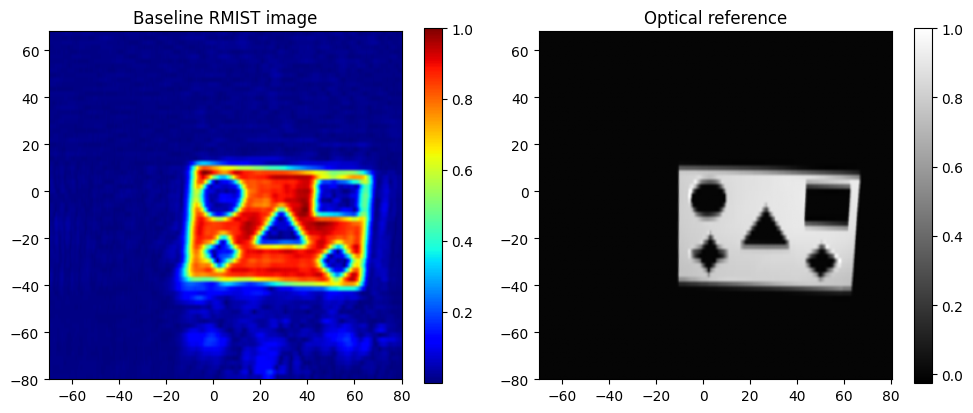


================ Image quality summary (NO-REFERENCE) ================
Baseline RMIST:
  Contrast : 2.688110
  Entropy  : 8.065384
  Peak     : 1.000000e+00

================ Image quality summary (REFERENCE) ================

Baseline RMIST vs Optical Reference:
MSE(Baseline,Optical)  : 1.0037e-02
NCC(Baseline,Optical)  : 0.9386
PSNR(Baseline,Optical) : 20.19 dB
SSIM(Baseline,Optical) : 0.4576


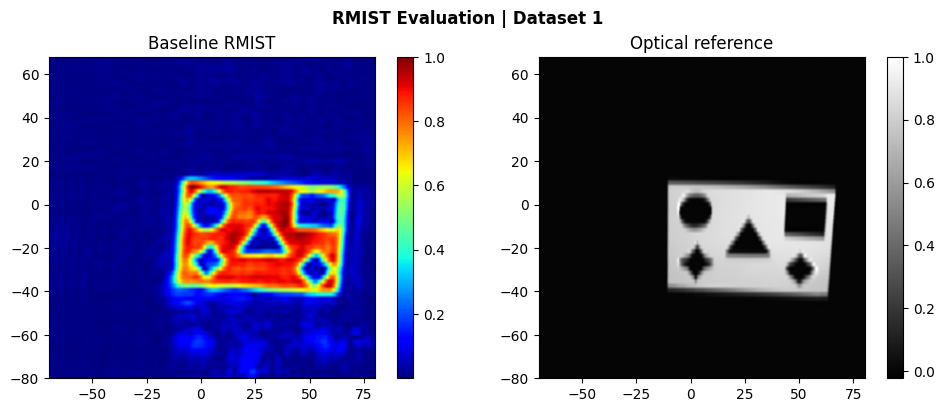

In [ ]:
# -------------------------
# Match optical size + normalization
# -------------------------


ref_optical_image = P["ref_optical_image"].copy()

if ref_optical_image.shape != baseline_img.shape:
    print(f"Resizing optical reference {ref_optical_image.shape} -> {baseline_img.shape}")
    ref_optical_image = resize_to_match(ref_optical_image, baseline_img.shape)

global_scale = np.max(np.abs(baseline_img)) + EPS
baseline_img = baseline_img / global_scale
ref_optical_image = ref_optical_image / (np.max(np.abs(ref_optical_image)) + EPS)

# -------------------------
# Show baseline + optical
# -------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    baseline_img,
    extent=[xAxis[0], xAxis[-1], yAxis[0], yAxis[-1]],
    origin="lower",
    cmap="jet",
    aspect="equal",
)
plt.colorbar()
plt.title("Baseline RMIST image")

plt.subplot(1, 2, 2)
plt.imshow(
    ref_optical_image,
    extent=[xAxis[0], xAxis[-1], yAxis[0], yAxis[-1]],
    origin="lower",
    cmap="gray",
    aspect="equal",
)
plt.colorbar()
plt.title("Optical reference")

plt.tight_layout()
plt.show()

# -------------------------
# No-reference metrics
# -------------------------
Q = image_quality_metrics(baseline_img)

print("\n================ Image quality summary (NO-REFERENCE) ================")
print("Baseline RMIST:")
print(f"  Contrast : {Q['contrast']:.6f}")
print(f"  Entropy  : {Q['entropy']:.6f}")
print(f"  Peak     : {Q['peak']:.6e}")
print("========================================================================")

# -------------------------
# Reference-based metrics
# -------------------------
R = compute_reference_metrics(baseline_img, ref_optical_image)

print("\n================ Image quality summary (REFERENCE) ================")
print(f"MSE(Baseline,Optical)     : {R['mse']:.4e}")
print(f"CosSim(Baseline,Optical)  : {R['cossim']:.4f}")
print(f"PSNR(Baseline,Optical)    : {R['psnr']:.2f} dB")
print(f"SSIM(Baseline,Optical)    : {R['ssim']:.4f}")

# -------------------------
# Final visualization
# -------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    baseline_img,
    extent=[xAxis[0], xAxis[-1], yAxis[0], yAxis[-1]],
    origin="lower",
    cmap="jet",
    aspect="equal",
)
plt.colorbar()
plt.title("Baseline RMIST")

plt.subplot(1, 2, 2)
plt.imshow(
    ref_optical_image,
    extent=[xAxis[0], xAxis[-1], yAxis[0], yAxis[-1]],
    origin="lower",
    cmap="gray",
    aspect="equal",
)
plt.colorbar()
plt.title("Optical reference")

plt.suptitle(f"RMIST Evaluation | Dataset {dataset}", fontweight="bold")
plt.tight_layout()
plt.show()

----------------
